# Knee Osteoarthritis Severity Classification (CNN)

## 1. Imports & Setup

In [226]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [227]:
dataset_path = "/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity"

train_dir = f"{dataset_path}/train"
val_dir   = f"{dataset_path}/val"
test_dir  = f"{dataset_path}/test"

classes = sorted(os.listdir(train_dir))
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['0', '1', '2', '3', '4']
Number of classes: 5


## 2.EDA



{'0': 2286, '1': 1046, '2': 1516, '3': 757, '4': 173}


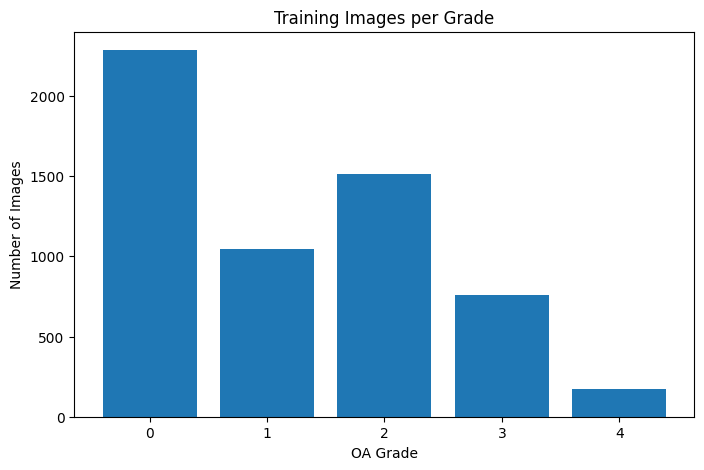

In [228]:
class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
print(class_counts)

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Training Images per Grade")
plt.xlabel("OA Grade")
plt.ylabel("Number of Images")
plt.show()

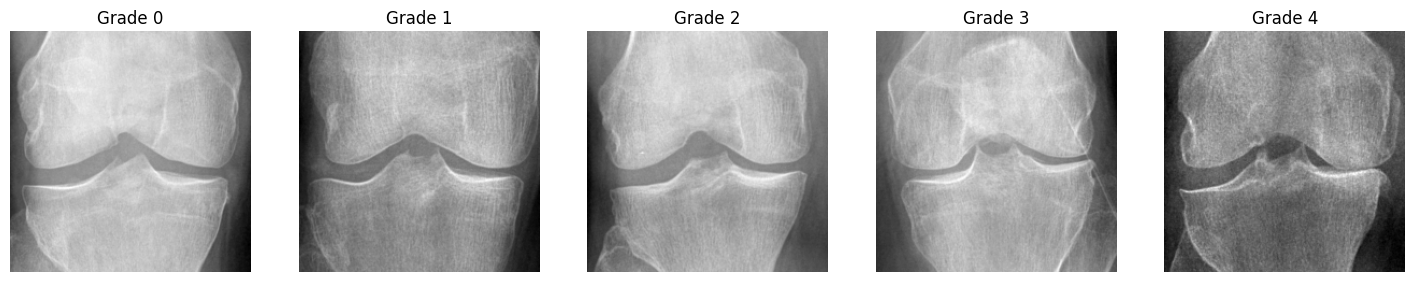

In [229]:
fig, axes = plt.subplots(1, len(classes), figsize=(18,4))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(train_dir, cls))[0]
    img = Image.open(os.path.join(train_dir, cls, img_name))
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Grade {cls}")
    axes[i].axis("off")

plt.show()

---
# Part A — Scratch CNN 

## 3. Preprocessing 


In [230]:
IMG_SIZE = 224

train_transform_cnn = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

eval_transform_cnn = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [231]:
def merge_grade1(label):
    if label <= 1:
        return 0        
    else:
        return label - 1  

classes_merged = ["0-1 (Normal/Doubtful)", "2 (Mild)", "3 (Moderate)", "4 (Severe)"]

train_dataset_cnn = ImageFolder(root=train_dir, transform=train_transform_cnn, target_transform=merge_grade1)
val_dataset_cnn   = ImageFolder(root=val_dir,   transform=eval_transform_cnn,  target_transform=merge_grade1)
test_dataset_cnn  = ImageFolder(root=test_dir,  transform=eval_transform_cnn,  target_transform=merge_grade1)

print(train_dataset_cnn.class_to_idx)
print("Classes after merge:", classes_merged)

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Classes after merge: ['0-1 (Normal/Doubtful)', '2 (Mild)', '3 (Moderate)', '4 (Severe)']


## 4. class weights 

.

In [232]:
BATCH_SIZE = 32

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn   = DataLoader(val_dataset_cnn,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_cnn  = DataLoader(test_dataset_cnn,  batch_size=BATCH_SIZE, shuffle=False)

targets = [merge_grade1(t) for t in train_dataset_cnn.targets]  
class_weights_raw = compute_class_weight(class_weight="balanced", classes=np.unique(targets), y=targets)
class_weights = torch.sqrt(torch.tensor(class_weights_raw, dtype=torch.float)).to(device)  
print("Raw class weights:", class_weights_raw)
print("Softened (sqrt) class weights:", class_weights)

Raw class weights: [0.43352341 0.95283641 1.90819022 8.34971098]
Softened (sqrt) class weights: tensor([0.6584, 0.9761, 1.3814, 2.8896], device='cuda:0')


## 5.Architecture 


In [233]:
class KneeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(KneeCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                 

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                    

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                   

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),                   

            nn.AdaptiveAvgPool2d((7, 7))        
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_cnn = KneeCNN(num_classes=len(classes_merged)).to(device)
print(model_cnn)

KneeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

## 6. Training loop 

In [234]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=25, patience=5, scheduler=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = correct / total

        if scheduler is not None:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (no val improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)
    return model, history

### Focal Loss

In [235]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha     
        self.gamma = gamma      

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)                    
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

In [236]:
criterion_cnn = FocalLoss(alpha=class_weights, gamma=2.0)  
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_cnn = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, mode="min", factor=0.5, patience=3)

model_cnn, history_cnn = train_model(
    model_cnn, train_loader_cnn, val_loader_cnn,
    criterion_cnn, optimizer_cnn,
    num_epochs=30, patience=6, scheduler=scheduler_cnn
)

Epoch [1/30] | Train Loss: 0.6782 | Train Acc: 0.4154 | Val Loss: 0.6433 | Val Acc: 0.4334
Epoch [2/30] | Train Loss: 0.6152 | Train Acc: 0.3906 | Val Loss: 0.6373 | Val Acc: 0.4964
Epoch [3/30] | Train Loss: 0.5835 | Train Acc: 0.4465 | Val Loss: 0.5709 | Val Acc: 0.5569
Epoch [4/30] | Train Loss: 0.5497 | Train Acc: 0.4367 | Val Loss: 0.5807 | Val Acc: 0.2579
Epoch [5/30] | Train Loss: 0.5341 | Train Acc: 0.4830 | Val Loss: 0.5650 | Val Acc: 0.5811
Epoch [6/30] | Train Loss: 0.5251 | Train Acc: 0.4785 | Val Loss: 0.5327 | Val Acc: 0.6077
Epoch [7/30] | Train Loss: 0.5150 | Train Acc: 0.4872 | Val Loss: 0.5023 | Val Acc: 0.6320
Epoch [8/30] | Train Loss: 0.4963 | Train Acc: 0.4972 | Val Loss: 0.6335 | Val Acc: 0.5460
Epoch [9/30] | Train Loss: 0.4976 | Train Acc: 0.4538 | Val Loss: 0.5036 | Val Acc: 0.6126
Epoch [10/30] | Train Loss: 0.4629 | Train Acc: 0.5069 | Val Loss: 0.5054 | Val Acc: 0.6065
Epoch [11/30] | Train Loss: 0.4700 | Train Acc: 0.4919 | Val Loss: 0.4674 | Val Acc: 0.54

## 7. test set

--- Scratch CNN ---
                       precision    recall  f1-score   support

0-1 (Normal/Doubtful)       0.82      0.61      0.70       935
             2 (Mild)       0.42      0.63      0.50       447
         3 (Moderate)       0.68      0.70      0.69       223
           4 (Severe)       0.68      0.78      0.73        51

             accuracy                           0.63      1656
            macro avg       0.65      0.68      0.66      1656
         weighted avg       0.69      0.63      0.65      1656



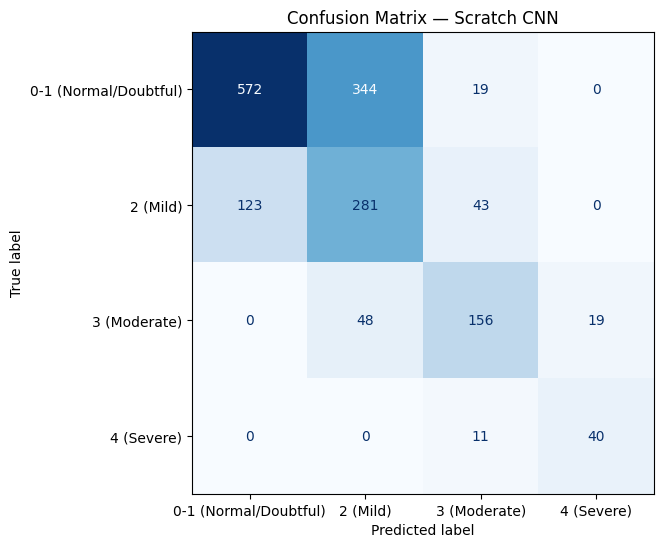

In [237]:
def evaluate_model(model, test_loader, class_names, title="Model"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(f"--- {title} ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {title}")
    plt.show()

    return all_labels, all_preds

labels_cnn, preds_cnn = evaluate_model(model_cnn, test_loader_cnn, classes_merged, title="Scratch CNN")

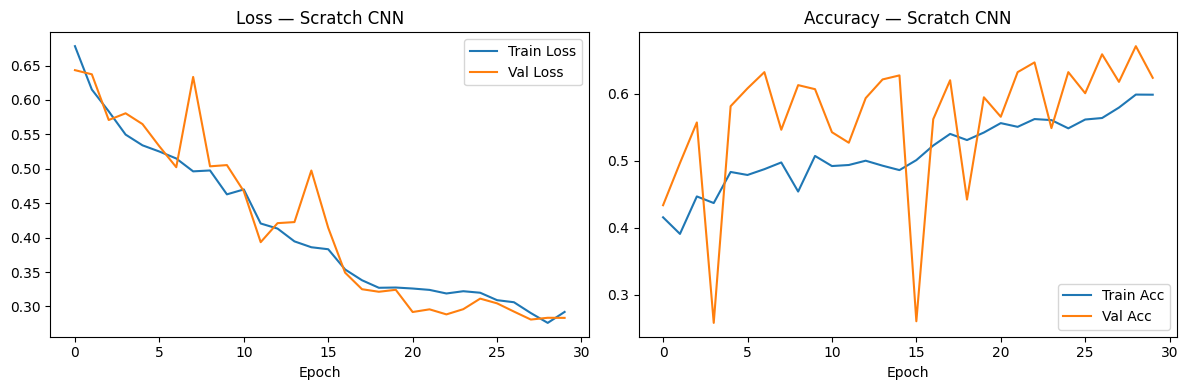

In [238]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cnn["train_loss"], label="Train Loss")
plt.plot(history_cnn["val_loss"], label="Val Loss")
plt.title("Loss — Scratch CNN")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn["train_acc"], label="Train Acc")
plt.plot(history_cnn["val_acc"], label="Val Acc")
plt.title("Accuracy — Scratch CNN")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

---
# Part B — Transfer Learning (ResNet18 pretrained on ImageNet)


In [239]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform_tl = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transform_tl = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset_tl = ImageFolder(root=train_dir, transform=train_transform_tl)
val_dataset_tl   = ImageFolder(root=val_dir,   transform=eval_transform_tl)
test_dataset_tl  = ImageFolder(root=test_dir,  transform=eval_transform_tl)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tl   = DataLoader(val_dataset_tl,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_tl  = DataLoader(test_dataset_tl,  batch_size=BATCH_SIZE, shuffle=False)

targets_tl = train_dataset_tl.targets
class_weights_tl_raw = compute_class_weight(class_weight="balanced", classes=np.unique(targets_tl), y=targets_tl)
class_weights_tl = torch.sqrt(torch.tensor(class_weights_tl_raw, dtype=torch.float)).to(device)   

## 9.  ResNet18 + fine-tuning

In [240]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for name, param in resnet.named_parameters():
    if not name.startswith("layer4") and not name.startswith("fc"):
        param.requires_grad = False

num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, len(classes))
)

model_tl = resnet.to(device)

trainable_params = [p for p in model_tl.parameters() if p.requires_grad]
print(f"Trainable params: {sum(p.numel() for p in trainable_params):,} / {sum(p.numel() for p in model_tl.parameters()):,}")

Trainable params: 8,526,341 / 11,309,125


In [241]:
criterion_tl = FocalLoss(alpha=class_weights_tl, gamma=2.0)   
optimizer_tl = torch.optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)
scheduler_tl = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_tl, mode="min", factor=0.5, patience=3)

model_tl, history_tl = train_model(
    model_tl, train_loader_tl, val_loader_tl,
    criterion_tl, optimizer_tl,
    num_epochs=20, patience=5, scheduler=scheduler_tl
)

Epoch [1/20] | Train Loss: 0.7314 | Train Acc: 0.3830 | Val Loss: 0.5559 | Val Acc: 0.4915
Epoch [2/20] | Train Loss: 0.5256 | Train Acc: 0.4785 | Val Loss: 0.4663 | Val Acc: 0.5424
Epoch [3/20] | Train Loss: 0.4538 | Train Acc: 0.5215 | Val Loss: 0.4702 | Val Acc: 0.5412
Epoch [4/20] | Train Loss: 0.4167 | Train Acc: 0.5284 | Val Loss: 0.4569 | Val Acc: 0.5799
Epoch [5/20] | Train Loss: 0.3940 | Train Acc: 0.5462 | Val Loss: 0.4188 | Val Acc: 0.5460
Epoch [6/20] | Train Loss: 0.3629 | Train Acc: 0.5815 | Val Loss: 0.5003 | Val Acc: 0.5484
Epoch [7/20] | Train Loss: 0.3363 | Train Acc: 0.5966 | Val Loss: 0.4464 | Val Acc: 0.5654
Epoch [8/20] | Train Loss: 0.3257 | Train Acc: 0.5916 | Val Loss: 0.4347 | Val Acc: 0.5787
Epoch [9/20] | Train Loss: 0.3276 | Train Acc: 0.5961 | Val Loss: 0.4451 | Val Acc: 0.5811
Epoch [10/20] | Train Loss: 0.2798 | Train Acc: 0.6312 | Val Loss: 0.4797 | Val Acc: 0.5387
Early stopping at epoch 10 (no val improvement for 5 epochs)


## 10. test set

--- ResNet18 Transfer Learning ---
              precision    recall  f1-score   support

           0       0.66      0.77      0.71       639
           1       0.26      0.36      0.30       296
           2       0.61      0.38      0.47       447
           3       0.77      0.61      0.69       223
           4       0.82      0.82      0.82        51

    accuracy                           0.57      1656
   macro avg       0.63      0.59      0.60      1656
weighted avg       0.60      0.57      0.57      1656



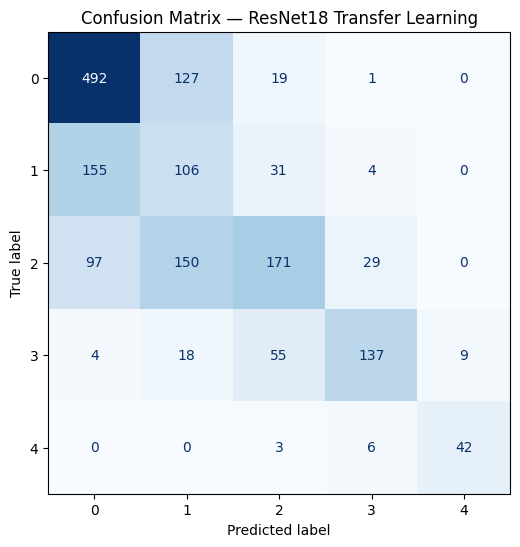

In [242]:
labels_tl, preds_tl = evaluate_model(model_tl, test_loader_tl, classes, title="ResNet18 Transfer Learning")

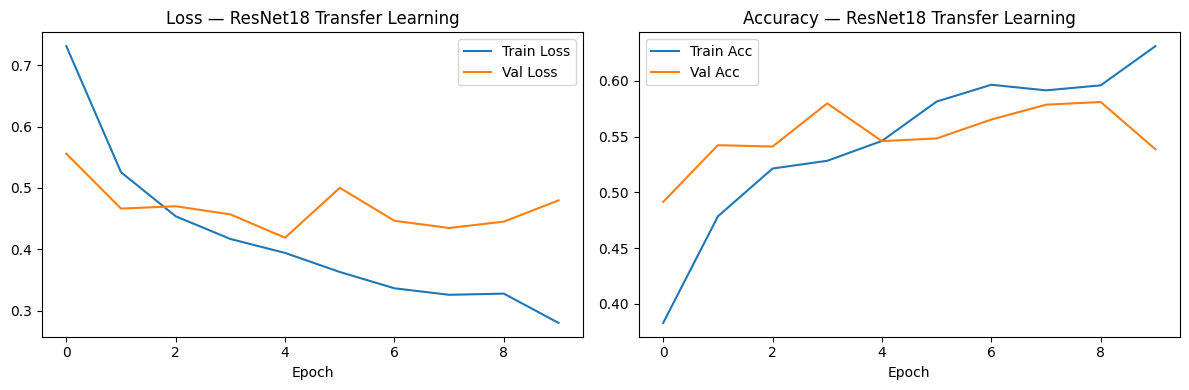

In [243]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_tl["train_loss"], label="Train Loss")
plt.plot(history_tl["val_loss"], label="Val Loss")
plt.title("Loss — ResNet18 Transfer Learning")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_tl["train_acc"], label="Train Acc")
plt.plot(history_tl["val_acc"], label="Val Acc")
plt.title("Accuracy — ResNet18 Transfer Learning")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

---
# 11. comparing

In [244]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def summarize(labels, preds, name):
    return {
        "Model": name,
        "Accuracy": accuracy_score(labels, preds),
        "Macro F1": f1_score(labels, preds, average="macro"),
        "Weighted Kappa": cohen_kappa_score(labels, preds, weights="quadratic")  
    }

import pandas as pd
results = pd.DataFrame([
    summarize(labels_cnn, preds_cnn, "Scratch CNN"),
    summarize(labels_tl, preds_tl, "ResNet18 Transfer Learning"),
])
results

,Model,Accuracy,Macro F1,Weighted Kappa
0,Scratch CNN,0.633454,0.655291,0.706924
1,ResNet18 Transfer Learning,0.572464,0.598642,0.746115
